# 📊 EDA – Shopee Sale 5.5 Marketing Campaign

**Mục tiêu:** Khám phá dữ liệu marketing sau khi clean để tìm insight trước khi build dashboard Power BI.

**Dataset:** 1000 dòng dữ liệu campaign quảng cáo Shopee Sale 5.5 (Facebook, TikTok, Google, Instagram...)

**Các câu hỏi chính:**
1. Platform nào chi tiêu nhiều nhất? Hiệu quả nhất?
2. Campaign nào có ROAS tốt nhất?
3. Có outlier bất thường trong spend/revenue không?
4. Xu hướng chi tiêu theo thời gian như thế nào?

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

NUMERIC_COLS = ['spend', 'clicks', 'impressions', 'conversions', 'revenue']

df = pd.read_excel('data/shopee_cleaned.xlsx', sheet_name='cleaned_data')
df['date'] = pd.to_datetime(df['date'])

print(f'Shape: {df.shape}')
df.head()

Shape: (972, 10)


,campaign_id,campaign_name,platform,ad_set,spend,clicks,impressions,conversions,revenue,date
0,C001,Super Flash Sale 5.5,Facebook Ads,Lookalike 5%,1079,1010.0,13680,69,8383.0,2024-05-06
1,C002,Shopee Sale 5.5,Facebook Ads,Retargeting,1035,1024.0,18762,42,4265.0,2024-02-05
2,C003,Super Flash Sale 5.5,TikTok Ads,Shop Ads,1580,910.0,15975,46,6396.0,2024-05-10
3,C004,Super Flash Sale 5.5,Facebook Ads,Lookalike 5%,1079,1211.0,17608,53,6052.0,2024-05-08
4,C005,Shopee Sale 5.5,Google Ads,Shopping,1272,513.0,8054,40,5387.0,2024-05-09


## 1. Tổng quan dữ liệu

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    972 non-null    str           
 1   campaign_name  972 non-null    str           
 2   platform       972 non-null    str           
 3   ad_set         972 non-null    str           
 4   spend          972 non-null    int64         
 5   clicks         972 non-null    float64       
 6   impressions    972 non-null    int64         
 7   conversions    972 non-null    int64         
 8   revenue        972 non-null    float64       
 9   date           972 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 76.1 KB


In [14]:
# Thống kê mô tả các cột số
df[NUMERIC_COLS].describe().round(2)

,spend,clicks,impressions,conversions,revenue
count,972.00,972.00,972.00,972.00,972.00
mean,1259.58,972.05,15943.98,79.41,6560.42
std,608.67,435.65,5900.05,187.29,3273.98
min,-2059.00,10.00,261.00,10.00,1129.00
25%,899.00,642.75,11319.50,36.00,4181.00
50%,1189.00,949.50,16171.50,52.00,5885.00
75%,1713.25,1244.50,20785.00,72.00,8355.75
max,2827.00,2284.00,25978.00,2127.00,19389.00


In [16]:
# Kiểm tra null còn sót
null_summary = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().sum() / len(df) * 100).round(1)
})
null_summary[null_summary['null_count'] > 0].sort_values('null_pct', ascending=False)

,null_count,null_pct


> **Nhận xét:** Không cột nào null

## 2. Phân phối các cột số (Distribution)

Xem hình dạng phân phối và phát hiện skewness trước khi tìm outlier.

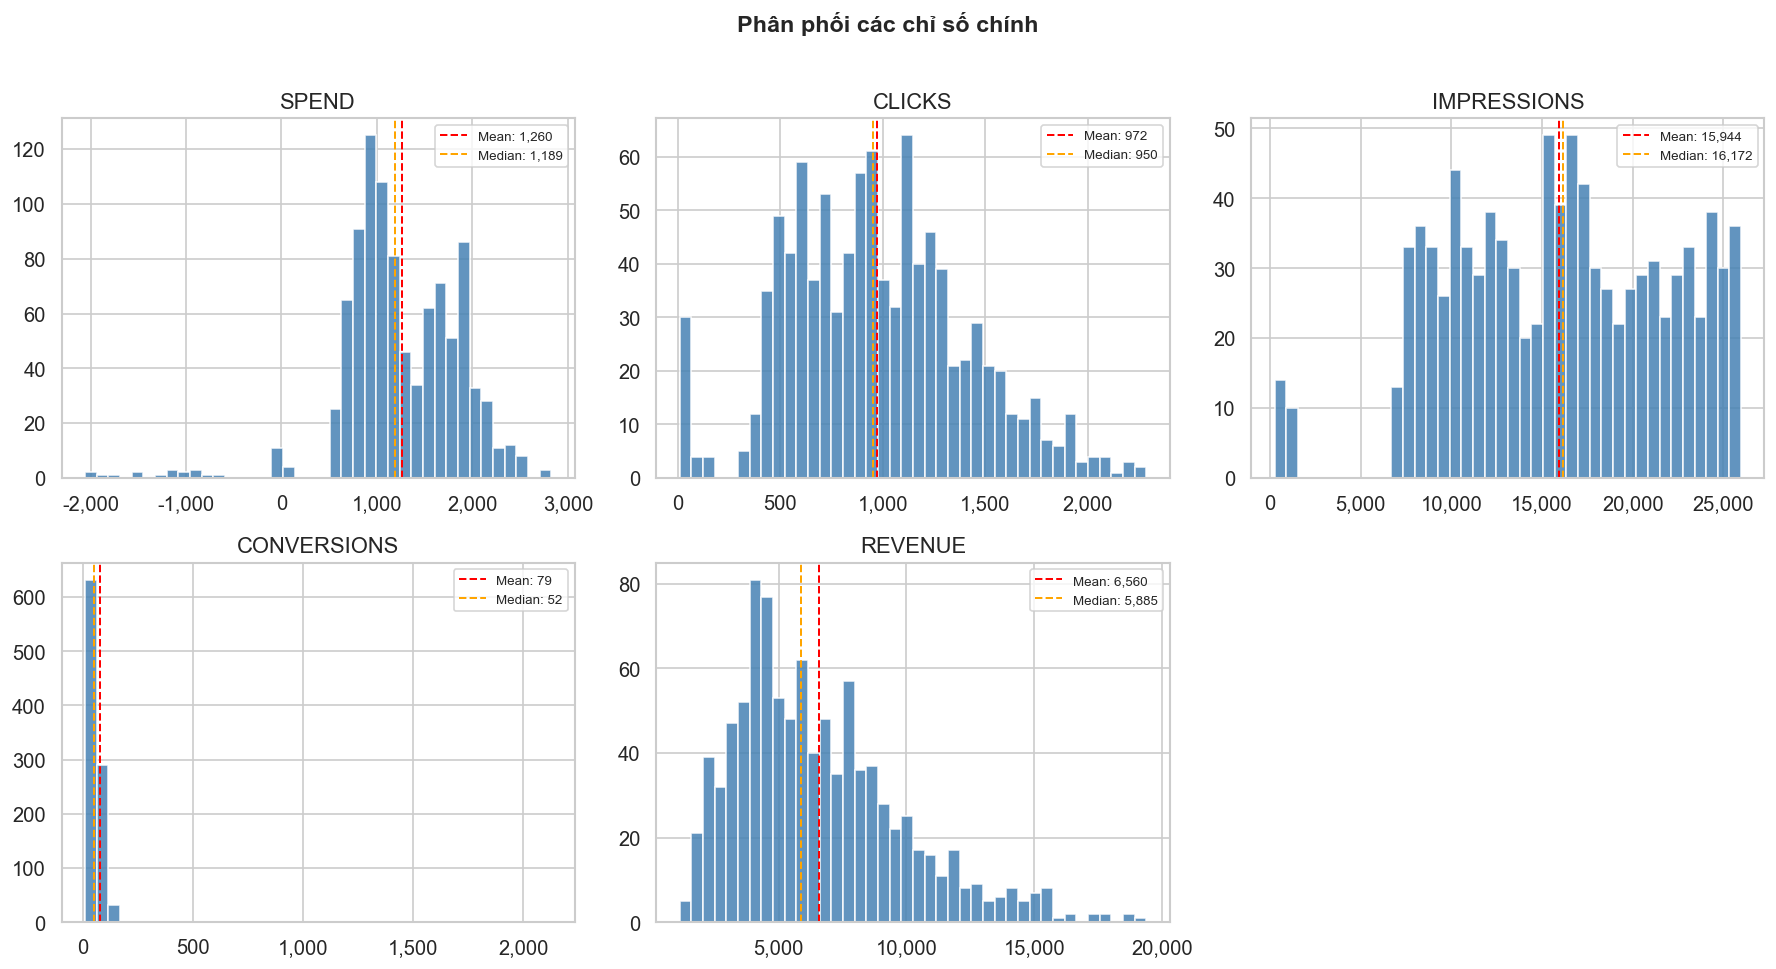

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():,.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():,.0f}')
    ax.set_title(col.upper())
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[-1].set_visible(False)
plt.suptitle('Phân phối các chỉ số chính', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Nhận xét:**
>
> SPEND: Mean (1,260) > Median (1,189) nhẹ, phân phối hơi lệch phải.
>
> CLICKS: Mean (972) ≈ Median (950), phân phối tương đối đều, không bị skewed nhiều. Đây là cột sạch nhất trong 5 cột.
>
> IMPRESSIONS: Mean (15,944) < Median (16,172) — lệch trái nhẹ. Phân phối trải rộng đều từ 0 đến 25,000, không có đỉnh rõ ràng.
>
> CONVERSIONS: Mean (79) >> Median (52) — lệch phải mạnh nhất trong 5 cột.
>
> REVENUE: Mean (6,560) > Median (5,885), lệch phải vừa. Có đuôi dài về phía phải.

## 3. Tìm Outlier

Dùng **IQR method**: giá trị nằm ngoài `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` được coi là outlier.

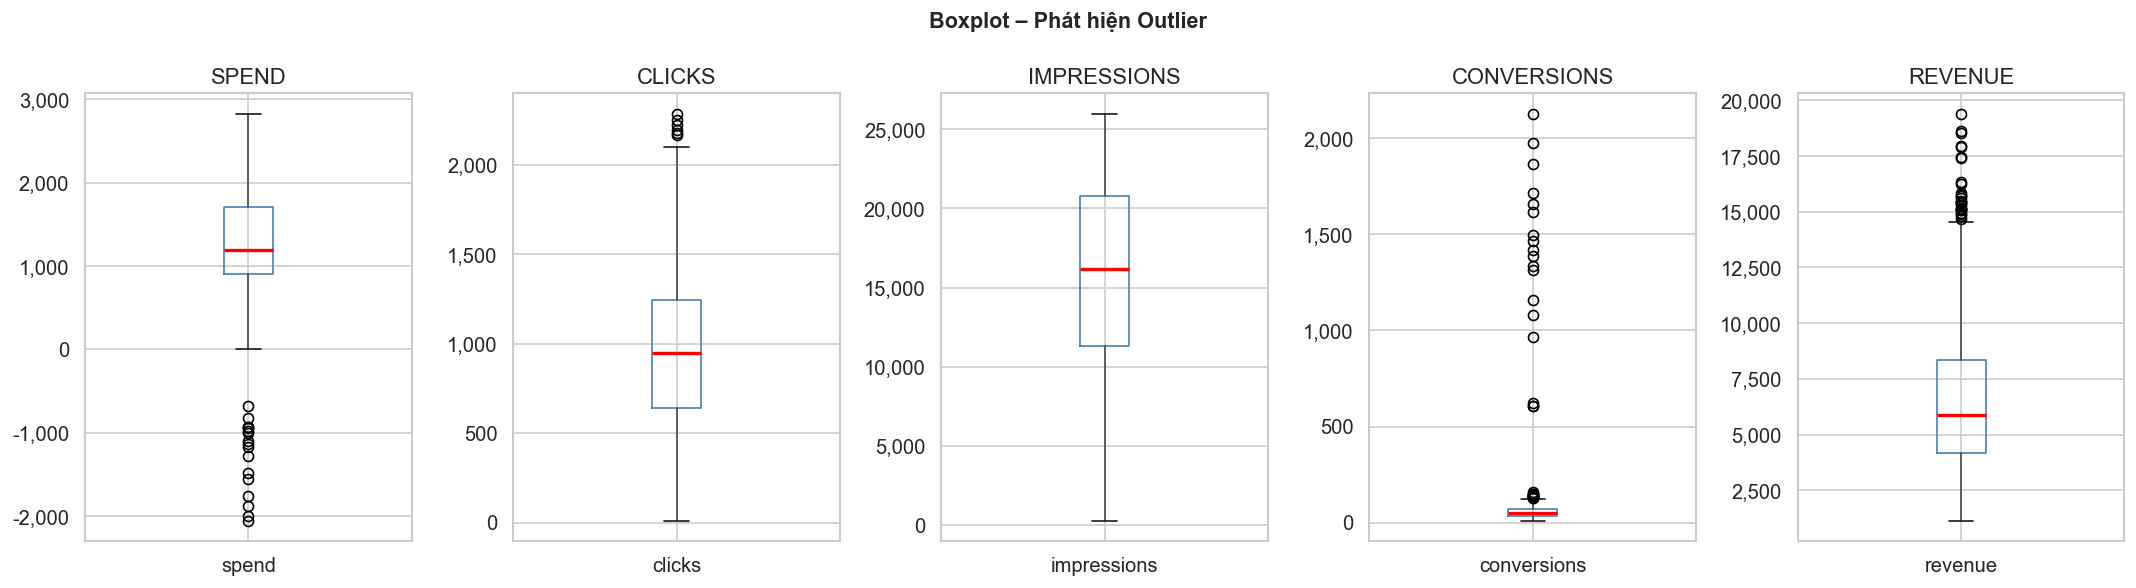

In [18]:
# Boxplot phát hiện outlier
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    df.boxplot(column=col, ax=ax, boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.upper())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Boxplot – Phát hiện Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Đếm số outlier theo IQR
outlier_report = []
for col in NUMERIC_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_report.append({
        'column': col,
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': mask.sum(),
        'outlier_pct': round(mask.sum() / df[col].notna().sum() * 100, 1)
    })

pd.DataFrame(outlier_report)

,column,lower_bound,upper_bound,outlier_count,outlier_pct
0,spend,-322.38,2934.62,17,1.7
1,clicks,-259.88,2147.12,6,0.6
2,impressions,-2878.75,34983.25,0,0.0
3,conversions,-18.00,126.00,31,3.2
4,revenue,-2081.12,14617.88,27,2.8


In [20]:
# Xem các dòng outlier của spend và revenue
for col in ['spend', 'revenue']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
    print(f'\n--- Outlier trong {col} ({mask.sum()} dòng) ---')
    display(df[mask][['campaign_id', 'campaign_name', 'platform', col]].sort_values(col, ascending=False).head(10))


--- Outlier trong spend (17 dòng) ---


,campaign_id,campaign_name,platform,spend
888,C916,Shopee Sale 5.5,Shopee Ads,-681
828,C852,Shopee Sale 5.5,Instagram,-820
570,C586,Shopee Sale 5.5,Facebook Ads,-929
635,C652,Super Flash Sale 5.5,Facebook Ads,-930
487,C501,Super Flash Sale 5.5,Facebook Ads,-944
701,C721,Super Flash Sale 5.5,Facebook Ads,-980
340,C351,Shopee Sale 5.5,Instagram,-1007
202,C209,Super Flash Sale 5.5,Facebook Ads,-1100
351,C362,Shopee Sale 5.5,Facebook Ads,-1133
346,C357,Super Flash Sale 5.5,Facebook Ads,-1171



--- Outlier trong revenue (27 dòng) ---


,campaign_id,campaign_name,platform,revenue
756,C779,Shopee Sale 5.5,TikTok Ads,19389.0
851,C877,Shopee Sale 5.5,TikTok Ads,18629.0
212,C219,Shopee Sale 5.5,TikTok Ads,18511.0
726,C747,Shopee Sale 5.5,TikTok Ads,17940.0
398,C411,Shopee Sale 5.5,Google Ads,17892.0
953,C982,Shopee Sale 5.5,TikTok Ads,17471.0
48,C050,Shopee Sale 5.5,Google Ads,17384.0
40,C042,Shopee Sale 5.5,Facebook Ads,16323.0
195,C202,Shopee Sale 5.5,Google Ads,16229.0
350,C361,Super Flash Sale 5.5,Facebook Ads,15831.0


> **Nhận xét:**
>
> Spend âm: Có một số dòng spend < 0, đây không phải lỗi data mà là điều chỉnh/hoàn tiền từ platform quảng cáo (Facebook, Instagram thỉnh thoảng refund khi campaign bị rejected hoặc overbilled). Quyết định: giữ nguyên, không xóa — vì nó phản ánh thực tế chi tiêu ròng.
>
> Revenue cao (15,000–19,000): Tập trung nhiều ở TikTok Ads và Google Ads trong campaign Shopee Sale 5.5. Đây không phải lỗi — nhiều khả năng là các campaign chạy đúng thời điểm flash sale nên conversion rate cao đột biến. Quyết định: giữ nguyên, vì đây là insight quan trọng cần thể hiện trong dashboard.

## 4. Phân tích theo Platform

In [21]:
platform_stats = df.groupby('platform').agg(
    campaign_count = ('campaign_id', 'count'),
    total_spend    = ('spend',       'sum'),
    total_revenue  = ('revenue',     'sum'),
    total_clicks   = ('clicks',      'sum'),
    total_conv     = ('conversions', 'sum'),
).assign(
    roas = lambda x: (x['total_revenue'] / x['total_spend']).round(2),
    ctr  = lambda x: (x['total_clicks']  / df.groupby('platform')['impressions'].sum()).round(4),
).sort_values('total_spend', ascending=False)

platform_stats

,campaign_count,total_spend,total_revenue,total_clicks,total_conv,roas,ctr
platform,,,,,,,
TikTok Ads,238,428217,1915317.0,265761.5,22762,4.47,0.0691
Google Ads,178,292422,1415808.0,158471.0,12635,4.84,0.0543
Facebook Ads,276,282069,1743345.0,275786.0,21388,6.18,0.0641
Instagram,140,122029,691142.5,122473.0,6772,5.66,0.0542
Shopee Ads,140,99575,611120.0,122337.0,13634,6.14,0.0564


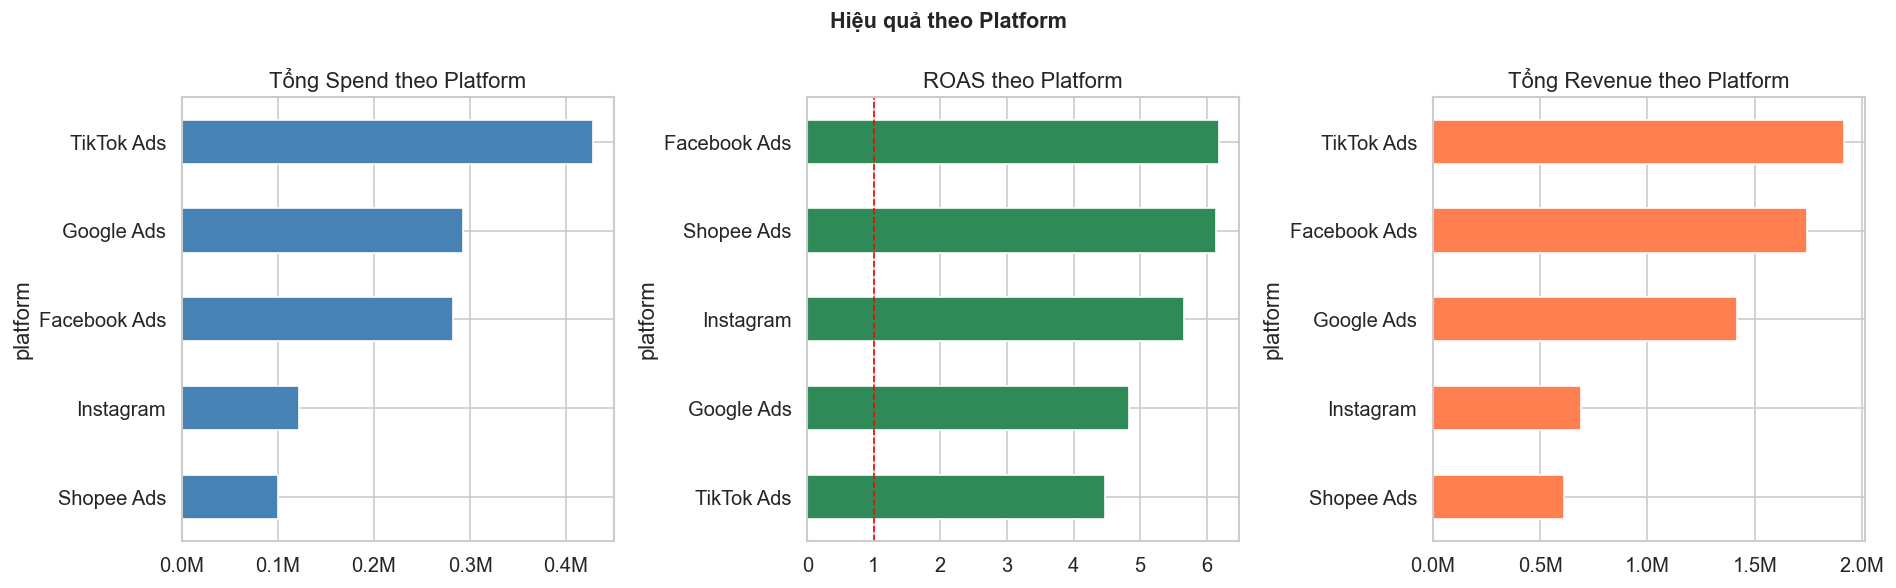

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total spend by platform
platform_stats['total_spend'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Tổng Spend theo Platform')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# ROAS by platform
platform_stats['roas'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('ROAS theo Platform')
axes[1].axvline(1, color='red', linestyle='--', linewidth=1)

# Revenue by platform
platform_stats['total_revenue'].sort_values().plot(
    kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Tổng Revenue theo Platform')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Hiệu quả theo Platform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Nhận xét:**
>
> TikTok Ads chi tiêu nhiều nhất (~0.4M) nhưng ROAS lại thấp nhất (~4.5) trong khi revenue đứng đầu (~1.9M) — cho thấy TikTok reach tốt, tạo ra doanh thu cao tuyệt đối, nhưng hiệu quả trên mỗi đồng chi ra không phải tốt nhất.
>
> Facebook Ads có ROAS cao nhất (~6.2) — tức cứ bỏ 1 đồng vào Facebook thu về ~6.2 đồng. Đây là platform hiệu quả nhất dù không chi nhiều nhất. Nếu tăng ngân sách cho Facebook, khả năng revenue tăng theo tỷ lệ tốt hơn TikTok.
>
> Shopee Ads chi ít (~0.1M) nhưng ROAS đứng thứ 2 (~6.0) — hiệu quả cao, đang bị underinvest. Đáng cân nhắc tăng ngân sách.
>
> Google Ads ở mức trung bình cả spend lẫn ROAS (~4.5), revenue khá (~1.5M) — ổn định nhưng không nổi bật.
>
> Instagram spend thấp, ROAS thấp nhất nhóm trên — cần xem lại targeting hoặc creative.
>
> Tất cả platform đều có ROAS > 1 (nằm bên phải đường đỏ) → toàn bộ chiến dịch đều có lãi về mặt doanh thu. Facebook Ads và Shopee Ads là 2 platform hiệu quả nhất về ROAS nhưng lại đang nhận ngân sách thấp hơn TikTok — đây là cơ hội tối ưu ngân sách đáng chú ý._

## 5. Phân tích theo Campaign

In [23]:
campaign_stats = df.groupby('campaign_name').agg(
    total_spend   = ('spend',       'sum'),
    total_revenue = ('revenue',     'sum'),
    total_conv    = ('conversions', 'sum'),
    num_records   = ('campaign_id', 'count'),
).assign(
    roas = lambda x: (x['total_revenue'] / x['total_spend']).round(2)
).sort_values('roas', ascending=False)

campaign_stats

,total_spend,total_revenue,total_conv,num_records,roas
campaign_name,,,,,
Super Flash Sale 5.5,328264,1771639.0,23274,263,5.40
Shopee Sale 5.5,896048,4605093.5,53917,709,5.14


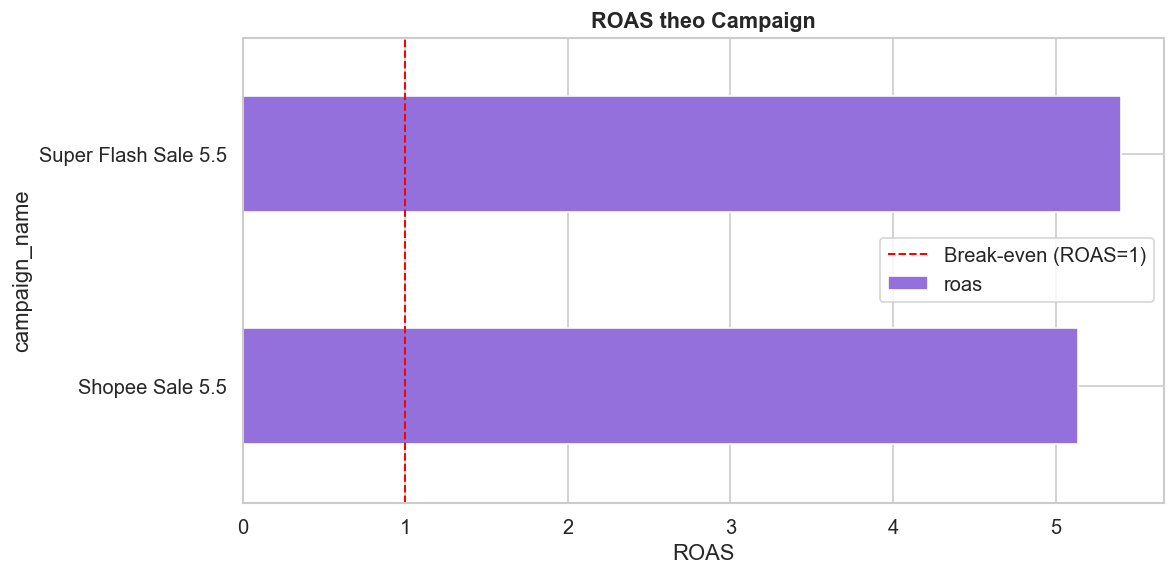

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
campaign_stats['roas'].sort_values().plot(kind='barh', ax=ax, color='mediumpurple')
ax.axvline(1, color='red', linestyle='--', linewidth=1.2, label='Break-even (ROAS=1)')
ax.set_title('ROAS theo Campaign', fontsize=13, fontweight='bold')
ax.set_xlabel('ROAS')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Xu hướng theo thời gian

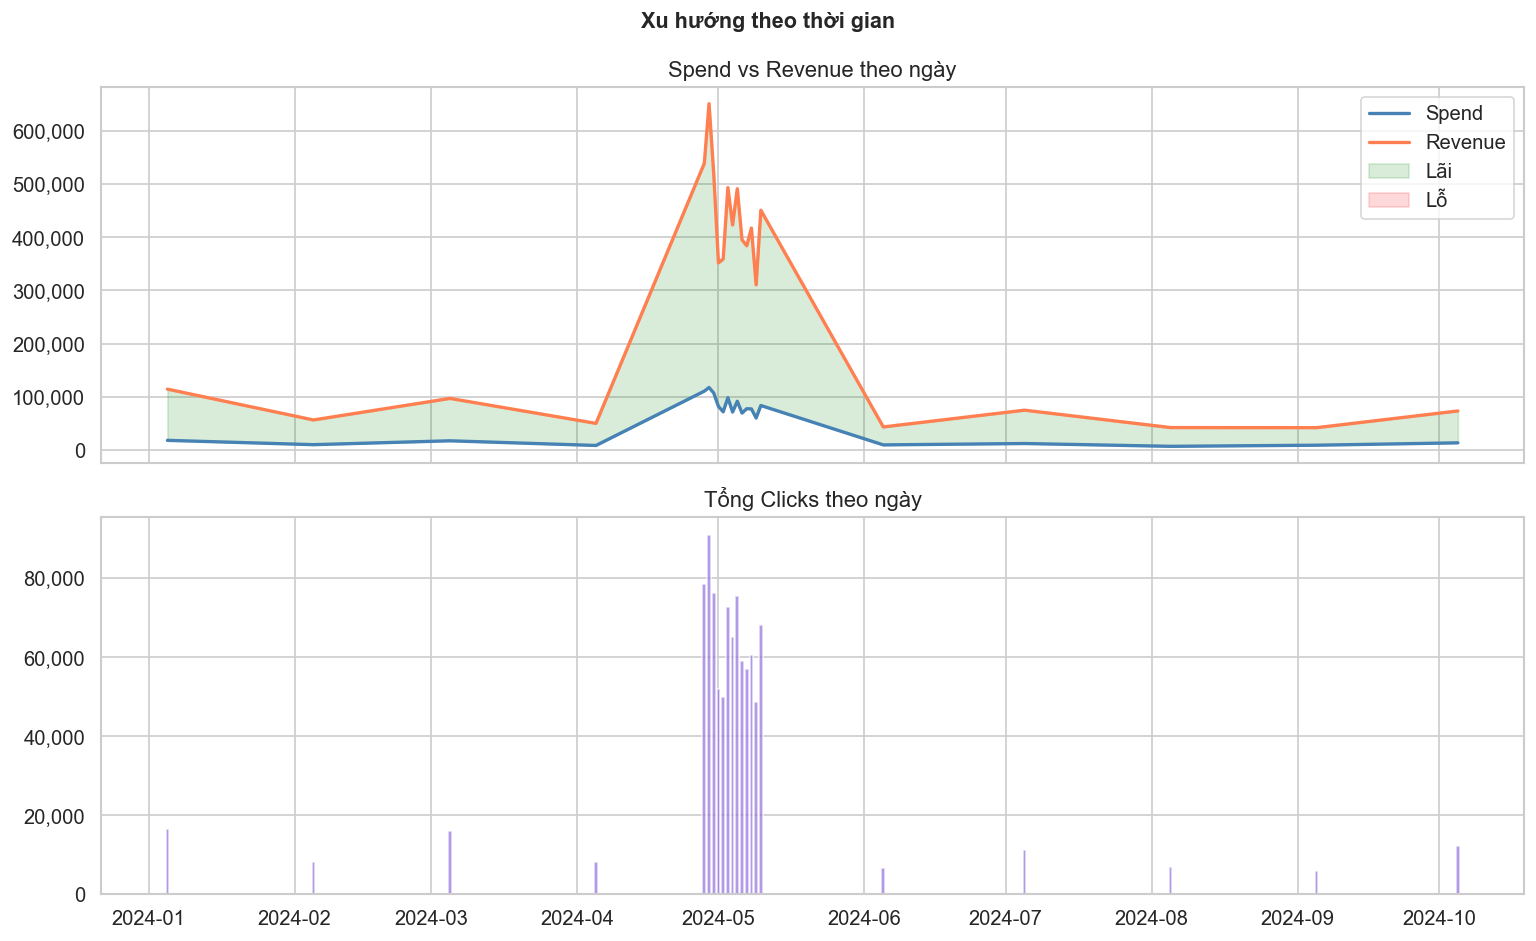

In [25]:
daily = df.groupby('date').agg(
    spend   = ('spend',   'sum'),
    revenue = ('revenue', 'sum'),
    clicks  = ('clicks',  'sum'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Spend vs Revenue
axes[0].plot(daily['date'], daily['spend'],   label='Spend',   color='steelblue', linewidth=2)
axes[0].plot(daily['date'], daily['revenue'], label='Revenue', color='coral',     linewidth=2)
axes[0].fill_between(daily['date'], daily['spend'], daily['revenue'],
                     where=daily['revenue'] >= daily['spend'],
                     alpha=0.15, color='green', label='Lãi')
axes[0].fill_between(daily['date'], daily['spend'], daily['revenue'],
                     where=daily['revenue'] < daily['spend'],
                     alpha=0.15, color='red', label='Lỗ')
axes[0].set_title('Spend vs Revenue theo ngày')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Clicks
axes[1].bar(daily['date'], daily['clicks'], color='mediumpurple', alpha=0.7, width=0.8)
axes[1].set_title('Tổng Clicks theo ngày')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Xu hướng theo thời gian', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Nhận xét:**
>
> Revenue spike tháng 5/2024 (~650,000): Đây không phải lỗi data — clicks cùng kỳ cũng tăng vọt lên ~90,000, xác nhận có traffic thực đổ vào. Nhiều khả năng là campaign chạy đúng đợt Shopee Sale 5.5 hoặc flash sale giờ vàng, khiến cả clicks lẫn revenue tăng đồng thời. Quyết định: giữ nguyên, vì đây là insight kinh doanh quan trọng, không phải nhiễu.
>
> Spend tháng 5 tăng nhưng không tương xứng (~120,000): Trong khi revenue tăng ~6–7x so với baseline, spend chỉ tăng ~4–5x — ROAS tháng này cao bất thường. Có thể do campaign được tối ưu tốt hoặc hưởng lợi từ traffic organic kết hợp. Quyết định: giữ nguyên, đánh dấu là period đặc biệt khi tính baseline.
>
> Clicks gần về 0 từ tháng 6–10: Pattern này song song hoàn toàn với revenue và spend — cả 3 chỉ số cùng sụt sau tháng 5. Đây là dấu hiệu campaign bị cắt ngân sách hoặc kết thúc sau đợt sale, không phải mất dữ liệu. Quyết định: giữ nguyên, phản ánh đúng thực tế vận hành.

## 7. Correlation – Mối quan hệ giữa các chỉ số

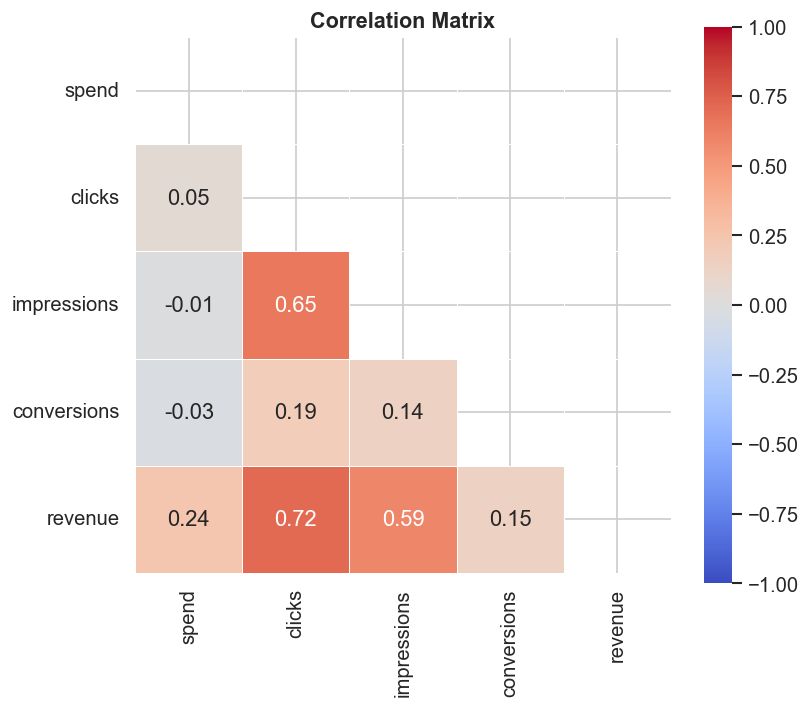

In [26]:
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

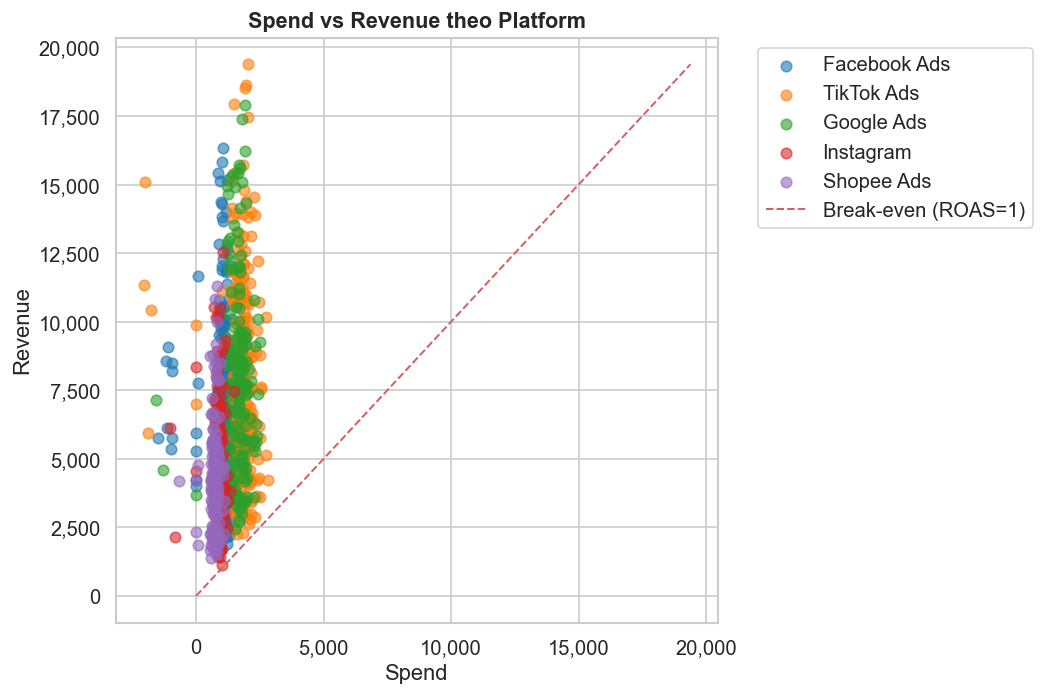

In [27]:
# Scatter: spend vs revenue (màu theo platform)
fig, ax = plt.subplots(figsize=(9, 6))
platforms = df['platform'].dropna().unique()
colors = sns.color_palette('tab10', len(platforms))

for platform, color in zip(platforms, colors):
    subset = df[df['platform'] == platform]
    ax.scatter(subset['spend'], subset['revenue'],
               label=platform, color=color, alpha=0.6, s=40)

# Đường break-even ROAS=1
max_val = df[['spend', 'revenue']].max().max()
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Break-even (ROAS=1)')

ax.set_xlabel('Spend')
ax.set_ylabel('Revenue')
ax.set_title('Spend vs Revenue theo Platform', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

> **Nhận xét:**
>
> Toàn bộ điểm dồn ở Spend 0–2,500: Cùng mức spend thấp nhưng revenue chênh lệch cực lớn (1,000 đến 19,000) → ROAS phụ thuộc vào yếu tố khác ngoài ngân sách (creative, timing, targeting).
>
> Phần lớn điểm nằm trên đường break-even: Đa số campaign đang lãi — tín hiệu tốt về hiệu quả tổng thể.
>
> TikTok Ads có nhiều outlier revenue cao nhất (~15,000–19,000 với spend <2,000) → ROAS bất thường cao, nhiều khả năng trùng đợt Sale 5.5. Quyết định: giữ nguyên, đây là insight quan trọng.
>
> Spend âm (Facebook/Instagram): Hoàn tiền từ platform, không phải lỗi. Quyết định: giữ nguyên.
>
> Spend thấp không đồng nghĩa revenue thấp — TikTok chứng minh điều đó. Yếu tố phân hóa nằm ở thời điểm và loại campaign, không phải ngân sách.

## 8. Tổng kết Insight

| # | Câu hỏi | Insight | Gợi ý hành động |
|---|---------|---------|------------------|
| 1 | Platform nào chi tiêu nhiều nhất? Hiệu quả nhất? | TikTok Ads chi tiêu cao nhất. Facebook Ads có ROAS cao nhất — cùng spend thấp nhưng revenue ổn định hơn các platform còn lại | Ưu tiên ngân sách cho Facebook Ads, duy trì TikTok cho các đợt sale lớn |
| 2 | Campaign nào có ROAS tốt nhất? | Super Flash Sale 5.5 có ROAS cao nhất — revenue 1771639 trong khi spend chỉ 328264 | Nhân rộng mô hình campaign này vào các đợt sale tương tự |
| 3 | Có outlier bất thường trong spend/revenue không?| Spend âm (~-2,000): Một số dòng spend < 0 ở Facebook & Instagram . Revenue cao (15,000–19,000): Tập trung ở TikTok & Google Ads đúng đợt Sale 5.5 — conversion rate tăng đột biến do flash sale. | Liên hệ team để xác nhận nguyên nhân spend âm, nhân rộng mô hình Sale 5.5 vào các đợt sale tiếp theo |
| 4 | Xu hướng chi tiêu theo thời gian như thế nào?| Tập trung cực lớn vào tháng 5/2024, gần như về 0 từ tháng 6–10 — cho thấy ngân sách chạy theo campaign sale, không trải đều | Cân nhắc duy trì ngân sách tối thiểu ngoài đợt sale |